# 01 - Eksplorativna analiza podataka (PlantVillage, color)

Cilj: razumeti dataset pre bilo kakvog modelovanja. Pošto je dataset
**neuravnotežen na oba nivoa hijerarhije**, centralni rezultat ovog notebook-a je
kvantifikovana slika tog disbalansa - ona opravdava strategiju evaluacije
(macro/weighted F1, balanced accuracy; **accuracy ne kao primarna metrika**).

Sekcije:
1. Setup i učitavanje sačuvanog split-a
2. Class distribution - Nivo 1 (vrste) i Nivo 2 (38 klasa)
3. Imbalance ratio po nivou
4. Mreža uzoraka slika po klasi
5. Dimenzije slika
6. Per-channel mean/std i color histogrami
7. Provera ispravnosti split-a (distribucija očuvana kroz train/val/test)

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Omogući da se `src` može import-ovati iz notebooks/ foldera.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.splits import load_split, split_summary, LabelMaps  # noqa: E402

sns.set_theme(style="whitegrid")

# Izmeni ako se tvoji sirovi podaci nalaze na drugom mestu.
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "plantvillage dataset" / "color"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT, "(exists:", DATA_ROOT.exists(), ")")

C:\Users\Marija\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: <repo>
DATA_ROOT   : <repo>\data\raw\plantvillage dataset\color (exists: True )


In [2]:
# Učitaj sačuvan, labeliran split. (Prvo pokreni scripts/prepare_splits.py.)
df = load_split(SPLITS_DIR, "all")
maps = LabelMaps.from_json(SPLITS_DIR / "label_maps.json")

print(f"Images : {len(df):,}")
print(f"Species (L1): {maps.num_species}  |  Classes (L2): {maps.num_classes}")
df.head()

Images : 54,305
Species (L1): 14  |  Classes (L2): 38


,filepath,class_name,species,disease,species_id,class_id,disease_id_in_species,split
0,Apple___Apple_scab/00075aa8-d81a-4184-8541-b69...,Apple___Apple_scab,Apple,Apple_scab,0,0,0,train
1,Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78...,Apple___Apple_scab,Apple,Apple_scab,0,0,0,val
2,Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620...,Apple___Apple_scab,Apple,Apple_scab,0,0,0,train
3,Apple___Apple_scab/0208f4eb-45a4-4399-904e-989...,Apple___Apple_scab,Apple,Apple_scab,0,0,0,train
4,Apple___Apple_scab/023123cb-7b69-4c9f-a521-766...,Apple___Apple_scab,Apple,Apple_scab,0,0,0,test


## 2. Class distribution

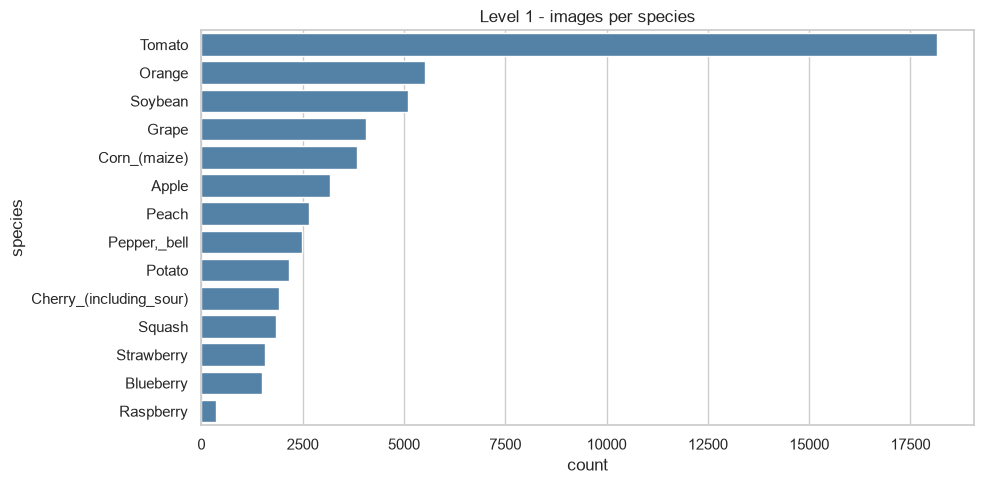

species
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64

In [3]:
# Nivo 1 - vrste
species_counts = df["species"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=species_counts.values, y=species_counts.index, ax=ax, color="steelblue")
ax.set(title="Level 1 - images per species", xlabel="count", ylabel="species")
plt.tight_layout()
plt.show()
species_counts

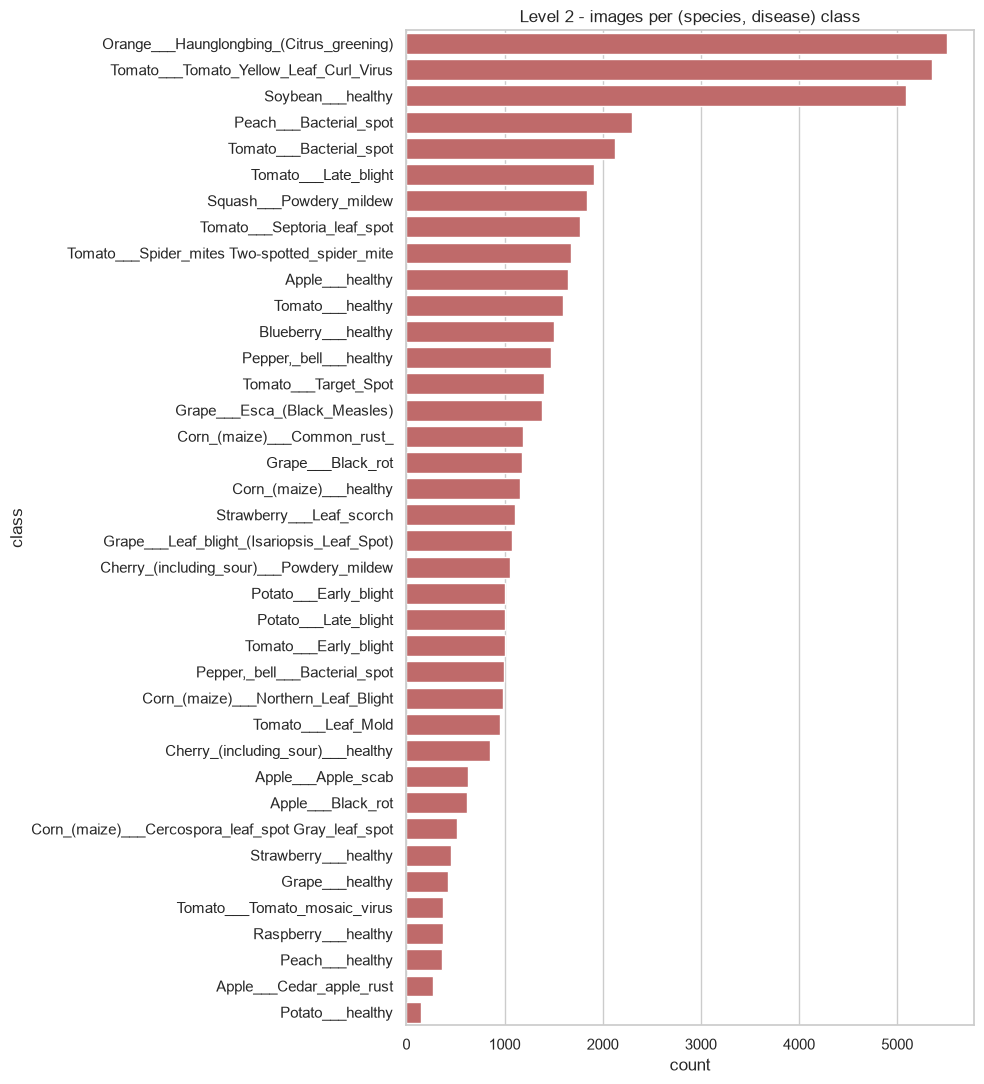

class_name
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                                  1404
Grape___Esca_(Black_Measles)                          1383
Corn_(maize)___Common_rust_                           1192
Grape___Black_rot                            

In [4]:
# Nivo 2 - punih 38 (vrsta, bolest) klasa
class_counts = df["class_name"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 11))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, color="indianred")
ax.set(title="Level 2 - images per (species, disease) class", xlabel="count", ylabel="class")
plt.tight_layout()
plt.show()
class_counts

## 3. Imbalance ratio

Imbalance ratio (max support / min support) je ključni broj koji
opravdava macro F1 umesto accuracy. Prikazan je na oba nivoa, plus po vrsti
(disbalans sa kojim se stvarno suočavaju klasifikatori bolesti po vrsti).

In [5]:
def imbalance_ratio(counts: pd.Series) -> float:
    return counts.max() / counts.min()

print(f"L1 (species) imbalance ratio : {imbalance_ratio(species_counts):.1f}x")
print(f"L2 (38-class) imbalance ratio: {imbalance_ratio(class_counts):.1f}x")

print("\nPer-species disease imbalance (within each species):")
for species in sorted(df["species"].unique()):
    sub = df.loc[df["species"] == species, "disease"].value_counts()
    ratio = imbalance_ratio(sub) if len(sub) > 1 else 1.0
    print(f"  {species:<28} {len(sub):>2} diseases  ratio={ratio:>5.1f}x  (n={sub.sum():,})")

L1 (species) imbalance ratio : 48.9x
L2 (38-class) imbalance ratio: 36.2x

Per-species disease imbalance (within each species):
  Apple                         4 diseases  ratio=  6.0x  (n=3,171)
  Blueberry                     1 diseases  ratio=  1.0x  (n=1,502)
  Cherry_(including_sour)       2 diseases  ratio=  1.2x  (n=1,906)
  Corn_(maize)                  4 diseases  ratio=  2.3x  (n=3,852)
  Grape                         4 diseases  ratio=  3.3x  (n=4,062)
  Orange                        1 diseases  ratio=  1.0x  (n=5,507)
  Peach                         2 diseases  ratio=  6.4x  (n=2,657)
  Pepper,_bell                  2 diseases  ratio=  1.5x  (n=2,475)
  Potato                        3 diseases  ratio=  6.6x  (n=2,152)
  Raspberry                     1 diseases  ratio=  1.0x  (n=371)
  Soybean                       1 diseases  ratio=  1.0x  (n=5,090)
  Squash                        1 diseases  ratio=  1.0x  (n=1,835)
  Strawberry                    2 diseases  ratio=  2.4x  

## 4. Uzorci slika po klasi

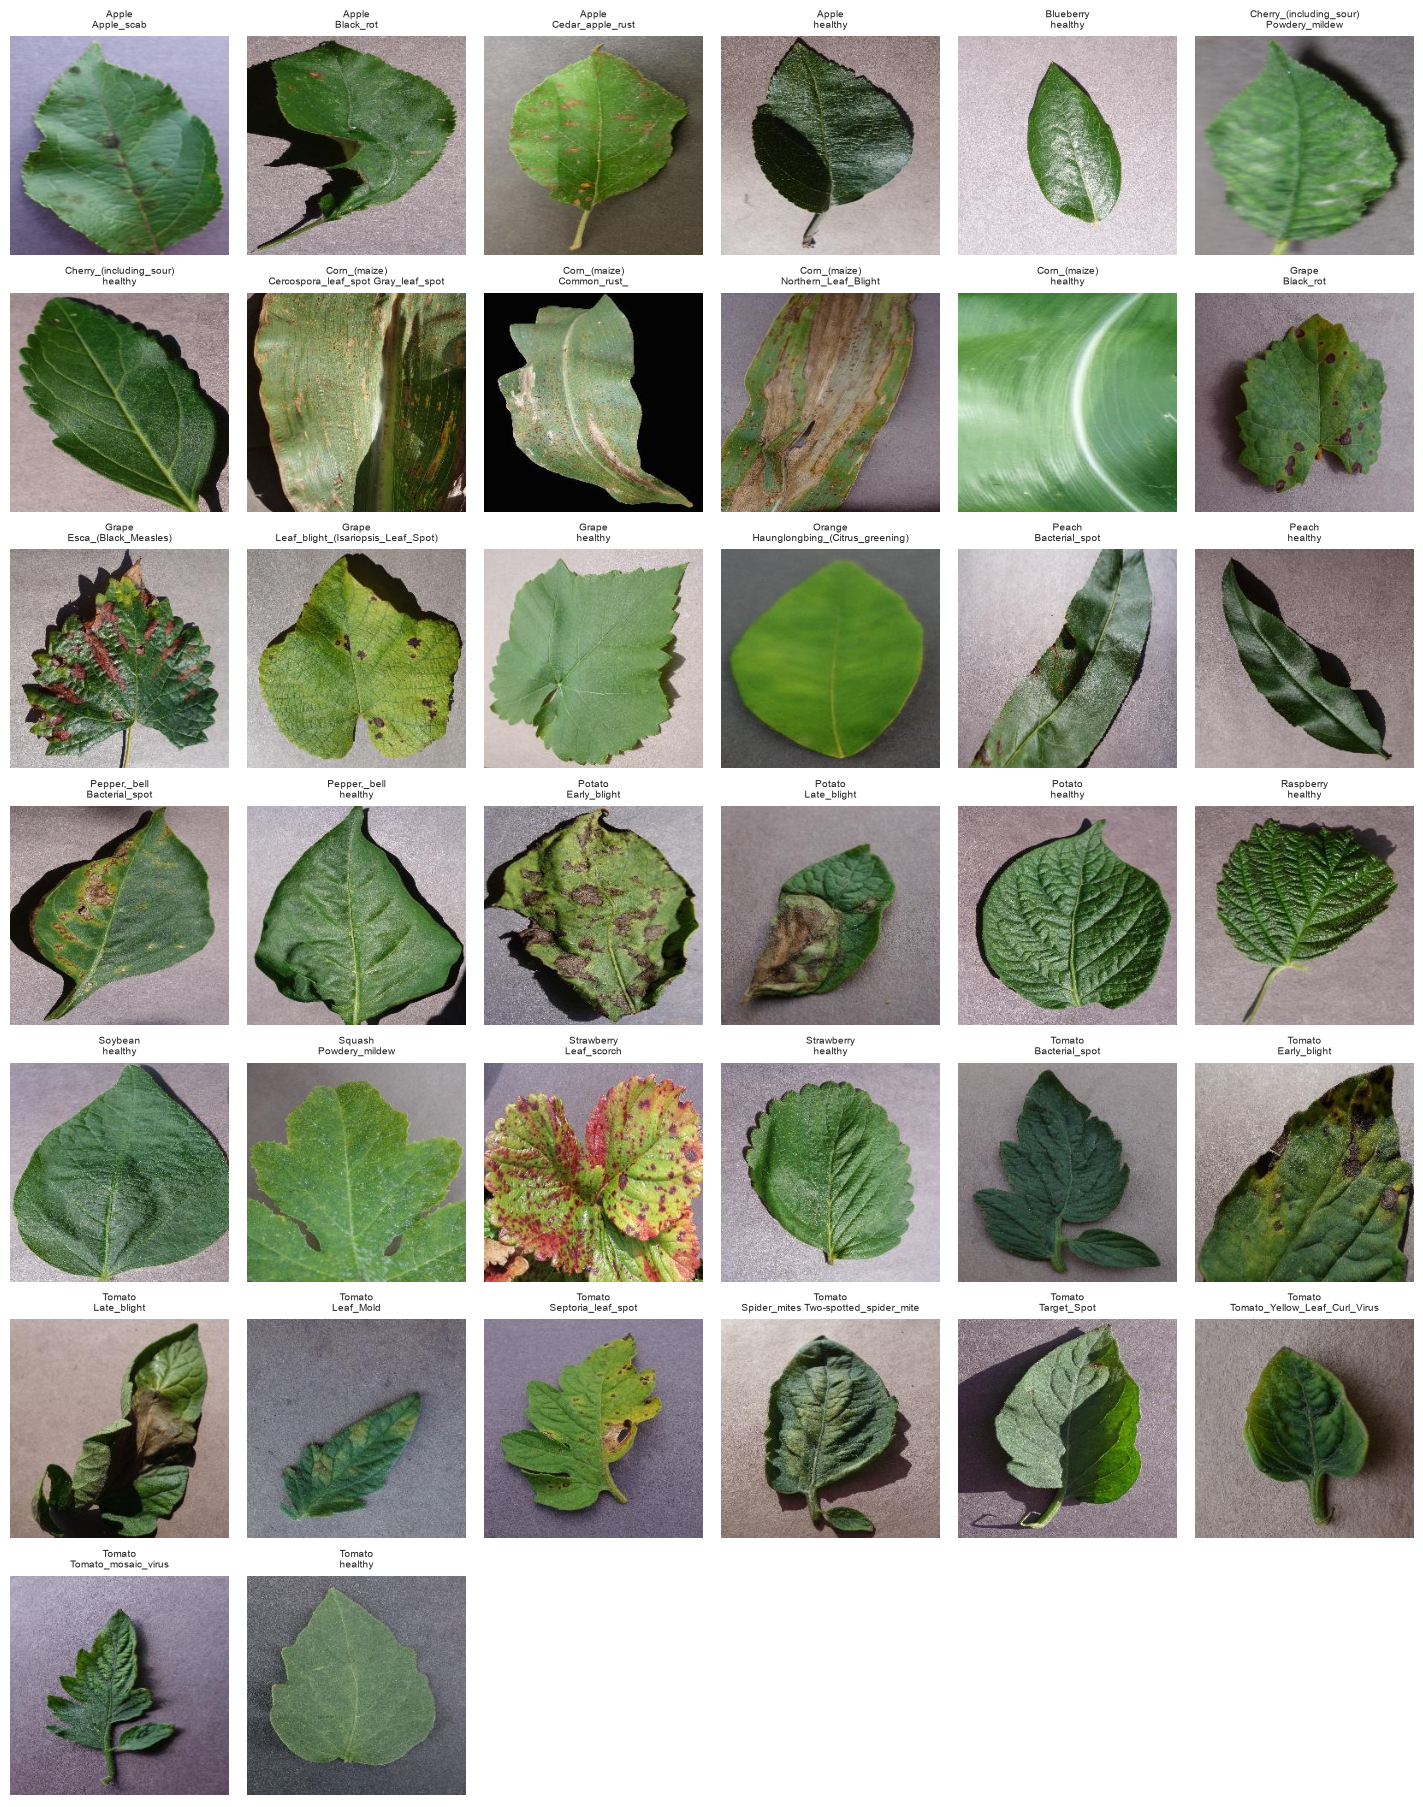

In [6]:
# Jedna reprezentativna slika po klasi. Ističe skoro uniformnu pozadinu po klasi
# koja izaziva poznati background bias problem kod PlantVillage skupa.
classes = sorted(df["class_name"].unique())
n = len(classes)
cols = 6
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.6))
for ax, cls in zip(axes.ravel(), classes):
    sample = df[df["class_name"] == cls].iloc[0]
    img = Image.open(DATA_ROOT / sample["filepath"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls.replace("___", "\n"), fontsize=7)
    ax.axis("off")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Dimenzije slika

In [7]:
# Uzorkuj podskup radi brzine; očekuje se da je PlantVillage color uniformno 256x256.
sample_df = df.sample(min(2000, len(df)), random_state=42)
dims = []
for fp in sample_df["filepath"]:
    with Image.open(DATA_ROOT / fp) as im:
        dims.append(im.size)  # (width, height)
dims = pd.DataFrame(dims, columns=["width", "height"])
print(dims.describe())
print("\nUnique (w, h) sizes:", sorted(set(map(tuple, dims.values))))

        width  height
count  2000.0  2000.0
mean    256.0   256.0
std       0.0     0.0
min     256.0   256.0
25%     256.0   256.0
50%     256.0   256.0
75%     256.0   256.0
max     256.0   256.0

Unique (w, h) sizes: [(np.int64(256), np.int64(256))]


## 6. Per-channel mean/std i color histogrami

Računaj samo na **train split-u** - ove statistike ulaze u normalizaciju i ne smeju
da procure val/test informacije.

In [8]:
train_df = df[df["split"] == "train"]
sample_train = train_df.sample(min(2000, len(train_df)), random_state=42)

psum = np.zeros(3)
psum_sq = np.zeros(3)
npix = 0
hist = np.zeros((3, 256), dtype=np.int64)
for fp in sample_train["filepath"]:
    arr = np.asarray(Image.open(DATA_ROOT / fp).convert("RGB"), dtype=np.float64) / 255.0
    pixels = arr.reshape(-1, 3)
    psum += pixels.sum(axis=0)
    psum_sq += (pixels ** 2).sum(axis=0)
    npix += pixels.shape[0]
    for c in range(3):
        hist[c] += np.bincount((arr[..., c] * 255).astype(int).ravel(), minlength=256)

mean = psum / npix
std = np.sqrt(psum_sq / npix - mean ** 2)
print("Per-channel mean (RGB):", np.round(mean, 4))
print("Per-channel std  (RGB):", np.round(std, 4))
print("(ImageNet ref mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225])")

Per-channel mean (RGB): [0.4614 0.4845 0.4044]
Per-channel std  (RGB): [0.1997 0.1756 0.2176]
(ImageNet ref mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225])


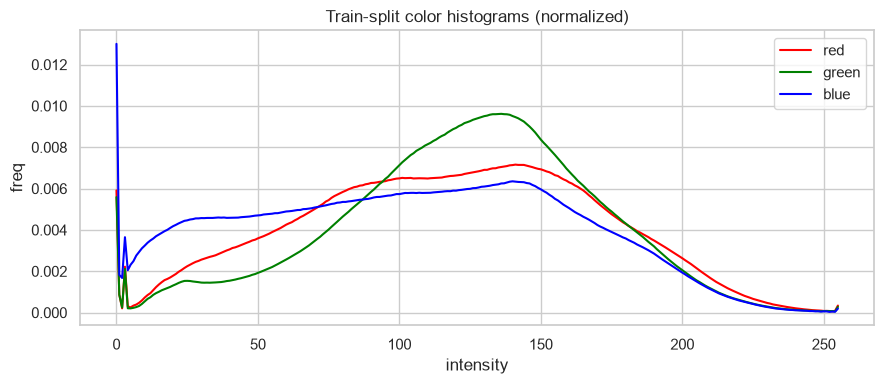

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
for c, color in enumerate(["red", "green", "blue"]):
    ax.plot(hist[c] / hist[c].sum(), color=color, label=color)
ax.set(title="Train-split color histograms (normalized)", xlabel="intensity", ylabel="freq")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Provera ispravnosti split-a

Potvrdi da je stratified split očuvao proporcije po klasi kroz
train/val/test (~70/15/15 svuda).

In [10]:
summary = split_summary(df)
props = summary[["train", "val", "test"]].div(summary["total"], axis=0)
print("Per-split proportion stats (should cluster around 0.70 / 0.15 / 0.15):")
print(props.describe().loc[["mean", "min", "max"]].round(3))
summary.head(10)

Per-split proportion stats (should cluster around 0.70 / 0.15 / 0.15):
split  train    val   test
mean   0.700  0.150  0.150
min    0.697  0.149  0.148
max    0.702  0.151  0.151


split,test,train,val,total
class_name,,,,
Orange___Haunglongbing_(Citrus_greening),826,3855,826,5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,803,3750,804,5357
Soybean___healthy,764,3563,763,5090
Peach___Bacterial_spot,344,1608,345,2297
Tomato___Bacterial_spot,319,1489,319,2127
Tomato___Late_blight,287,1336,286,1909
Squash___Powdery_mildew,275,1284,276,1835
Tomato___Septoria_leaf_spot,265,1240,266,1771
Tomato___Spider_mites Two-spotted_spider_mite,252,1173,251,1676
